In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('ai4i2020.csv')

# 2. Gereksiz ve "Kopya Çeken" Sütunları Temizle, Hedef değişkenimiz: Machine failure
X = df.drop(['UDI', 'Product ID', 'Type', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df['Machine failure']

# 3. Eğitim ve Test Setine Ayır (%80 - %20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

print("Veri Hazırlama Tamamlandı!")
print(f"Eğitim Satır Sayısı: {len(X_train)}, Test Satır Sayısı: {len(X_test)}")
X.head() # Sütunları kontrol et

Veri Hazırlama Tamamlandı!
Eğitim Satır Sayısı: 8000, Test Satır Sayısı: 2000


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,298.1,308.6,1551,42.8,0
1,298.2,308.7,1408,46.3,3
2,298.1,308.5,1498,49.4,5
3,298.2,308.6,1433,39.5,7
4,298.2,308.7,1408,40.0,9


In [2]:
# Modelleri ve denenecek ayarları (Hiperparametreleri) tanımlıyoruz
model_params = {
    'RandomForest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [50, 100],
            'max_depth': [5, 10, None]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(),
        'params': {
            'n_estimators': [50, 100],
            'learning_rate': [0.1, 0.05]
        }
    }
}

scores = []
best_estimators = {}

print("Modeller yarıştırılıyor ve en iyi parametreler aranıyor (Bu işlem 1-2 dk sürebilir)...")

for model_name, mp in model_params.items():
    # GridSearchCV her model için tüm parametre kombinasyonlarını dener (AutoML mantığı)
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    
    scores.append({
        'Model': model_name,
        'En İyi Skor (CV)': clf.best_score_,
        'En İyi Parametreler': clf.best_params_
    })
    best_estimators[model_name] = clf.best_estimator_

# Sonuçları tablo olarak göster
results_df = pd.DataFrame(scores)
print("\n--- AutoML Liderlik Tablosu ---")
print(results_df)

Modeller yarıştırılıyor ve en iyi parametreler aranıyor (Bu işlem 1-2 dk sürebilir)...

--- AutoML Liderlik Tablosu ---
              Model  En İyi Skor (CV)  \
0      RandomForest          0.982625   
1  GradientBoosting          0.983000   

                           En İyi Parametreler  
0      {'max_depth': None, 'n_estimators': 50}  
1  {'learning_rate': 0.1, 'n_estimators': 100}  


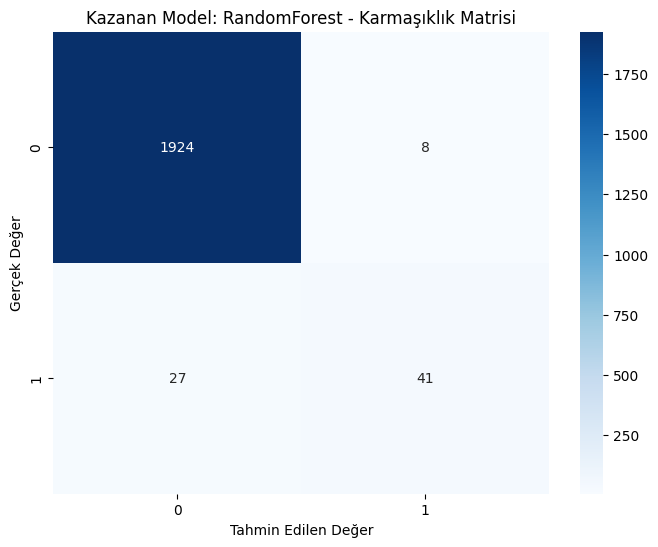


--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.84      0.60      0.70        68

    accuracy                           0.98      2000
   macro avg       0.91      0.80      0.85      2000
weighted avg       0.98      0.98      0.98      2000



In [3]:
# Tablodaki en iyi modeli seç (Genelde RandomForest veya GradientBoosting olur)
# Hangisi daha yüksekse onu yazabilirsin, biz genel olarak ilkini alalım:
winner_name = results_df.iloc[0]['Model']
winner_model = best_estimators[winner_name]

# Test verisiyle tahmin yap
y_pred = winner_model.predict(X_test)

# Grafik Çizimi
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Kazanan Model: {winner_name} - Karmaşıklık Matrisi')
plt.ylabel('Gerçek Değer')
plt.xlabel('Tahmin Edilen Değer')
plt.show()

print("\n--- Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred))